# Local image-generation model comparison

One of my projects is to represent Swedish vocabulary with simple flashcard illustrations. Whenever I learn a new word, I would like to generate a small, recognisable image that can later be used in a flashcard.

Large hosted image models can usually produce better illustrations, but this notebook explores whether smaller **local, free image-generation models** are good enough for this purpose.

## Goal

Compare several local image-generation models on the same small flashcard task and record:

- how to install and download each model;
- whether it runs successfully on my Mac;
- generation time;
- image quality and recognisability;
- memory or numerical-precision problems encountered during testing.

The main comparison uses three models:

1. Stable Diffusion 1.5
2. SD-Turbo
3. SSD-1B
4. FLUX.1-schnell is also documented as an additional experiment because it proved too large for this machine.

## Computer and software setup

The local image-generation experiments in this notebook were run on:

### Hardware

- **Computer:** MacBook Pro
- **Chip:** Apple M4
- **CPU:** 10 cores (4 performance + 6 efficiency)
- **Unified memory:** 24 GB
- **Architecture:** ARM64
- **Storage:** 1 TB SSD

### Software

- **Operating system:** macOS 15.7.7
- **Python:** 3.13.2
- **PyTorch:** 2.13.0
- **Diffusers:** 0.39.0
- **Transformers:** 5.14.1
- **PyTorch MPS backend:** available

The models are executed locally using PyTorch's MPS backend, which allows
PyTorch to use the Apple Silicon GPU.

Hardware and software versions are recorded because model compatibility,
memory consumption, numerical precision, and generation speed can differ
substantially between systems.

## 1. Environment and required packages

Activate the project virtual environment first, then install the packages below in Terminal.

```bash
source .venv/bin/activate

python -m pip install -U \
    torch \
    torchvision \
    diffusers \
    transformers \
    accelerate \
    safetensors \
    pillow \
    pandas \
    matplotlib \
    ipython \
    huggingface_hub
```

The Hugging Face CLI is used to download model files separately in Terminal. This keeps downloading separate from model loading inside Jupyter.

## 2. Imports and hardware check

The imports below are shared by all model experiments.

In [1]:
from pathlib import Path
from time import perf_counter
import gc

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageStat
from IPython.display import display

import torch

from diffusers import (
    StableDiffusionPipeline,
    StableDiffusionXLPipeline,
    AutoPipelineForText2Image,
)


[transformers] `Siglip2ImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `Siglip2ImageProcessor` instead.


In [2]:
# Apple Silicon can use the MPS backend in PyTorch.
device = "mps" if torch.backends.mps.is_available() else "cpu"

print("PyTorch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())
print("MPS built:", torch.backends.mps.is_built())
print("Selected device:", device)

PyTorch version: 2.13.0
MPS available: True
MPS built: True
Selected device: mps


## 3. Shared benchmark setup

To make the comparison meaningful, all models receive the same five objects and the same basic style description.

The five test words are:

- A – **anka** – duck
- B – **bil** – car
- K – **katt** – cat
- Ä – **äpple** – apple
- Ö – **öga** – eye

English object names are used in the image prompts because these image models generally understand English prompts better.

In [3]:
test_objects = [
    ("A", "anka", "duck"),
    ("B", "bil", "car"),
    ("K", "katt", "cat"),
    ("Ä", "äpple", "apple"),
    ("Ö", "öga", "eye"),
]

### Shared prompt

The same style target is used for every model:

- cute children's illustration;
- one object only;
- soft pastel colours;
- simple cartoon style;
- rounded friendly shapes;
- pure plain white background;
- no text.

In [4]:
def make_prompt(object_name: str) -> str:
    """Create the shared positive prompt for one object."""
    return f"""
    cute children's illustration of a {object_name},
    one {object_name} only,
    soft pastel colors,
    clean simple cartoon style,
    rounded friendly shapes,
    pure plain white background,
    no text
    """

### Shared negative prompt

A negative prompt tells compatible models which visual properties to avoid.

In [5]:
negative_prompt = """
ugly, blurry, distorted,
extra limbs, extra wings,
multiple objects,
text, letters, watermark,
messy background,
dark background,
photorealistic
"""

## 4. Shared helper functions

The benchmark now uses a visible four-stage flow:

1. `prepare_generation_jobs()` creates prompts, settings, and output paths. It does **not** run the model.
2. `run_model()` runs the Diffusers pipeline and measures each generation. The exact model-execution line is `result = pipe(**job["generation_args"])`.
3. `save_model_outputs()` validates and saves the generated images.
4. `get_results_summary()` creates the final DataFrame with the columns `model`, `letter`, `word`, `object_english`, `runtime_sec`, and `image_path`.

Display remains separate through `show_results_horizontal()` and `show_comparison_grid()`. This makes it clear which notebook cell performs expensive inference and which cells only prepare, save, summarize, or display existing results.


In [6]:
RESULT_COLUMNS = [
    "model",
    "letter",
    "word",
    "object_english",
    "runtime_sec",
    "image_path",
]


def is_nearly_black(image, mean_threshold=1.0, spread_threshold=1.0):
    """Return True when an image is effectively a uniform black frame."""
    rgb_image = image.convert("RGB")
    stats = ImageStat.Stat(rgb_image)
    mean_brightness = sum(stats.mean) / len(stats.mean)
    channel_spread = max(extreme[1] - extreme[0] for extreme in stats.extrema)
    return mean_brightness <= mean_threshold and channel_spread <= spread_threshold


def prepare_generation_jobs(
    model_name,
    output_folder,
    num_inference_steps,
    guidance_scale,
    use_negative_prompt=True,
):
    """Prepare the five benchmark jobs without running the model."""
    output_dir = Path(output_folder)
    jobs = []

    for letter, swedish_word, english_object in test_objects:
        generation_args = {
            "prompt": make_prompt(english_object),
            "width": 512,
            "height": 512,
            "num_inference_steps": num_inference_steps,
            "guidance_scale": guidance_scale,
        }

        if use_negative_prompt:
            generation_args["negative_prompt"] = negative_prompt

        jobs.append(
            {
                "model": model_name,
                "letter": letter,
                "word": swedish_word,
                "object_english": english_object,
                "image_path": output_dir / f"{letter}_{swedish_word}.png",
                "generation_args": generation_args,
            }
        )

    return jobs


def run_model(pipe, generation_jobs):
    """Run the model for every prepared job and return in-memory outputs."""
    run_records = []

    for job in generation_jobs:
        start = perf_counter()

        # This is the exact line that runs the image-generation model.
        result = pipe(**job["generation_args"])

        elapsed = perf_counter() - start
        image = result.images[0]

        if is_nearly_black(image):
            raise RuntimeError(
                f"{job['model']} returned a nearly black image for "
                f"{job['object_english']}. This usually indicates non-finite "
                "values from an unstable dtype. Existing files were not overwritten."
            )

        run_records.append(
            {
                **job,
                "runtime_sec": round(elapsed, 2),
                "image": image,
            }
        )

    return run_records


def save_model_outputs(run_records):
    """Save validated in-memory images to their prepared output paths."""
    for record in run_records:
        image_path = Path(record["image_path"])
        image_path.parent.mkdir(parents=True, exist_ok=True)
        record["image"].save(image_path)


def get_results_summary(run_records):
    """Return the standard six-column benchmark summary DataFrame."""
    rows = []

    for record in run_records:
        rows.append(
            {
                "model": record["model"],
                "letter": record["letter"],
                "word": record["word"],
                "object_english": record["object_english"],
                "runtime_sec": record["runtime_sec"],
                "image_path": str(record["image_path"]),
            }
        )

    return pd.DataFrame(rows, columns=RESULT_COLUMNS)


### Detailed workflow and data flow

The final result remains the same six-column DataFrame. The extra stages exist only to make every implementation step visible.

| Stage | Function | Implementation | Output |
|---|---|---|---|
| 1. Prepare | `prepare_generation_jobs()` | Loops through `test_objects`, calls `make_prompt()`, creates Diffusers keyword arguments, and constructs each PNG path. | A list of job dictionaries. No model inference occurs. |
| 2. Run | `run_model()` | Starts `perf_counter()`, executes `result = pipe(**job["generation_args"])`, reads `result.images[0]`, and records elapsed seconds. | A list of run records containing the in-memory PIL images and timing. This is the expensive stage. |
| 3. Validate | `is_nearly_black()` inside `run_model()` | Uses `ImageStat` to measure brightness and channel spread. A nearly uniform black output raises an error before existing files can be overwritten. | Validated in-memory images. |
| 4. Save | `save_model_outputs()` | Creates the output directory with `mkdir()` and saves each PIL image to its prepared path. | PNG files under `model_test_outputs/<model>/`. |
| 5. Summarize | `get_results_summary()` | Selects only the public metadata, converts `Path` objects to strings, orders the six columns with `RESULT_COLUMNS`, and constructs a pandas DataFrame. | The requested six-column result table. |
| 6. Display | `show_results_horizontal()` | Opens the saved paths and draws the five images with Matplotlib. | A figure; the result DataFrame is not modified. |

In [7]:
def show_results_horizontal(results_df):
    """Display one model's five saved images in a horizontal row."""
    if results_df.empty:
        raise ValueError("results_df is empty")

    n = len(results_df)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.5), squeeze=False)

    for ax, row in zip(axes.flat, results_df.itertuples(index=False)):
        with Image.open(row.image_path) as image:
            ax.imshow(image.convert("RGB"))
        ax.set_title(f"{row.letter} – {row.word}\n{row.runtime_sec:.2f} s", fontsize=10)
        ax.axis("off")

    fig.suptitle(results_df["model"].iloc[0], fontsize=14, y=1.02)
    fig.tight_layout()
    plt.show()


def show_comparison_grid(results_df, model_order, object_order, output_path=None):
    """Display all 15 images and optionally save the comparison figure."""
    expected = len(model_order) * len(object_order)
    if len(results_df) != expected:
        raise ValueError(f"Expected {expected} results, received {len(results_df)}")

    lookup = results_df.set_index(["model", "object_english"])
    fig, axes = plt.subplots(
        len(model_order),
        len(object_order),
        figsize=(3 * len(object_order), 3.2 * len(model_order)),
        squeeze=False,
    )

    for row_index, model_name in enumerate(model_order):
        for column_index, object_name in enumerate(object_order):
            row = lookup.loc[(model_name, object_name)]
            ax = axes[row_index, column_index]
            with Image.open(row.image_path) as image:
                ax.imshow(image.convert("RGB"))
            ax.set_title(
                f"{row.letter} – {row.word}\n{row.runtime_sec:.2f} s",
                fontsize=10,
            )
            ax.axis("off")

            if column_index == 0:
                ax.set_ylabel(model_name, fontsize=12, fontweight="bold")

    fig.suptitle("Local image-generation comparison: all 15 images", fontsize=16)
    fig.tight_layout(rect=(0, 0, 0, 0))
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()


def release_pipeline(pipe):
    """Move a pipeline off MPS and release unified memory."""
    pipe.to("cpu")
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()


## 5. Model comparison

Each model section follows the same sequence:

1. download the model in Terminal;
2. load the model from the local Hugging Face cache;
3. generate the same five images with `generate_test_images()`;
4. inspect the images and runtime;
5. record any model-specific observations.

## Model 1 — Stable Diffusion 1.5

### Download

Run in Terminal:

```bash
hf download stable-diffusion-v1-5/stable-diffusion-v1-5
```

### Load

On this Mac, `float16` on MPS produced black images. Using `float32` fixed the problem, so this notebook uses `float32` for SD 1.5.

The legacy safety checker is disabled here because it repeatedly produced false-positive NSFW detections for harmless educational flashcard prompts.

In [8]:
sd15 = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float32,
    local_files_only=True,
    safety_checker=None,
    requires_safety_checker=False,
)

sd15 = sd15.to(device)

# Attention slicing can reduce peak memory usage.
sd15.enable_attention_slicing()

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

### Prepare SD 1.5 jobs

This cell only prepares prompts, generation settings, and output paths. It does not run the model.


In [9]:
sd15_jobs = prepare_generation_jobs(
    model_name="SD 1.5",
    output_folder="model_test_outputs/sd15",
    num_inference_steps=25,
    guidance_scale=7.5,
    use_negative_prompt=True,
)

sd15_jobs


[{'model': 'SD 1.5',
  'letter': 'A',
  'word': 'anka',
  'object_english': 'duck',
  'image_path': PosixPath('model_test_outputs/sd15/A_anka.png'),
  'generation_args': {'prompt': "\n    cute children's illustration of a duck,\n    one duck only,\n    soft pastel colors,\n    clean simple cartoon style,\n    rounded friendly shapes,\n    pure plain white background,\n    no text\n    ",
   'width': 512,
   'height': 512,
   'num_inference_steps': 25,
   'guidance_scale': 7.5,
   'negative_prompt': '\nugly, blurry, distorted,\nextra limbs, extra wings,\nmultiple objects,\ntext, letters, watermark,\nmessy background,\ndark background,\nphotorealistic\n'}},
 {'model': 'SD 1.5',
  'letter': 'B',
  'word': 'bil',
  'object_english': 'car',
  'image_path': PosixPath('model_test_outputs/sd15/B_bil.png'),
  'generation_args': {'prompt': "\n    cute children's illustration of a car,\n    one car only,\n    soft pastel colors,\n    clean simple cartoon style,\n    rounded friendly shapes,\n    

### Run SD 1.5

The next cell is the expensive step. The `run_model()` call is where all five images are generated.


In [10]:
sd15_runs = run_model(
    pipe=sd15,
    generation_jobs=sd15_jobs,
)

save_model_outputs(sd15_runs)

sd15_results = get_results_summary(sd15_runs)
sd15_results


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

,model,letter,word,object_english,runtime_sec,image_path
0,SD 1.5,A,anka,duck,25.31,model_test_outputs/sd15/A_anka.png
1,SD 1.5,B,bil,car,24.91,model_test_outputs/sd15/B_bil.png
2,SD 1.5,K,katt,cat,24.93,model_test_outputs/sd15/K_katt.png
3,SD 1.5,Ä,äpple,apple,25.51,model_test_outputs/sd15/Ä_äpple.png
4,SD 1.5,Ö,öga,eye,26.11,model_test_outputs/sd15/Ö_öga.png


### Show the images


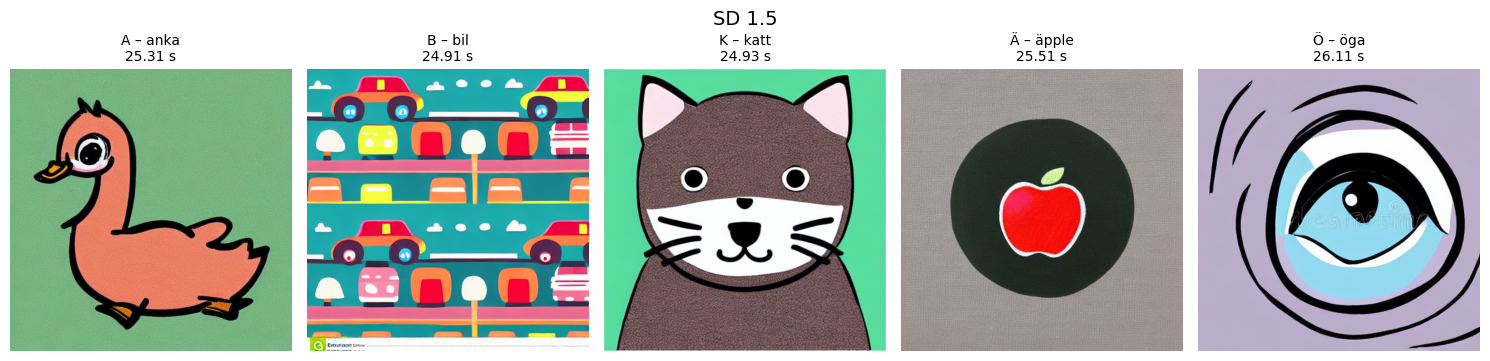

In [11]:
show_results_horizontal(sd15_results)

In [12]:
release_pipeline(sd15)
del sd15


### Observation

With `torch.float16` on MPS, SD 1.5 produced black images on this machine. Switching to `torch.float32` fixed the problem.

The generated objects are recognisable, but the illustration quality is relatively abstract compared with the stronger models tested later.

## Model 2 — SD-Turbo

SD-Turbo is included mainly as a **speed-oriented** model. Unlike the other models, it is designed to work with very few inference steps.

### Download

Run in Terminal:

```bash
hf download stabilityai/sd-turbo
```

### Load

For stability on this Mac, the example below uses `float32`.

In [13]:
sd_turbo = AutoPipelineForText2Image.from_pretrained(
    "stabilityai/sd-turbo",
    torch_dtype=torch.float32,
    local_files_only=True,
)

sd_turbo = sd_turbo.to(device)

/Users/changliu/Documents/data-lab/.venv/lib/python3.13/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/372 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


### Prepare SD-Turbo jobs

This cell only prepares prompts, generation settings, and output paths. It does not run the model.


In [14]:
sd_turbo_jobs = prepare_generation_jobs(
    model_name="SD-Turbo",
    output_folder="model_test_outputs/sd_turbo",
    num_inference_steps=2,
    guidance_scale=0.0,
    use_negative_prompt=False
)

sd_turbo_jobs


[{'model': 'SD-Turbo',
  'letter': 'A',
  'word': 'anka',
  'object_english': 'duck',
  'image_path': PosixPath('model_test_outputs/sd_turbo/A_anka.png'),
  'generation_args': {'prompt': "\n    cute children's illustration of a duck,\n    one duck only,\n    soft pastel colors,\n    clean simple cartoon style,\n    rounded friendly shapes,\n    pure plain white background,\n    no text\n    ",
   'width': 512,
   'height': 512,
   'num_inference_steps': 2,
   'guidance_scale': 0.0}},
 {'model': 'SD-Turbo',
  'letter': 'B',
  'word': 'bil',
  'object_english': 'car',
  'image_path': PosixPath('model_test_outputs/sd_turbo/B_bil.png'),
  'generation_args': {'prompt': "\n    cute children's illustration of a car,\n    one car only,\n    soft pastel colors,\n    clean simple cartoon style,\n    rounded friendly shapes,\n    pure plain white background,\n    no text\n    ",
   'width': 512,
   'height': 512,
   'num_inference_steps': 2,
   'guidance_scale': 0.0}},
 {'model': 'SD-Turbo',
  'l

### Run SD-Turbo

The next cell is the expensive step. The `run_model()` call is where all five images are generated.


In [15]:
sd_turbo_runs = run_model(
    pipe=sd_turbo,
    generation_jobs=sd_turbo_jobs,
)

save_model_outputs(sd_turbo_runs)

sd_turbo_results = get_results_summary(sd_turbo_runs)
sd_turbo_results

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

,model,letter,word,object_english,runtime_sec,image_path
0,SD-Turbo,A,anka,duck,1.61,model_test_outputs/sd_turbo/A_anka.png
1,SD-Turbo,B,bil,car,1.68,model_test_outputs/sd_turbo/B_bil.png
2,SD-Turbo,K,katt,cat,1.58,model_test_outputs/sd_turbo/K_katt.png
3,SD-Turbo,Ä,äpple,apple,1.77,model_test_outputs/sd_turbo/Ä_äpple.png
4,SD-Turbo,Ö,öga,eye,1.65,model_test_outputs/sd_turbo/Ö_öga.png


Mark: The change of parameters does not change the picture quality much.

### Show the images

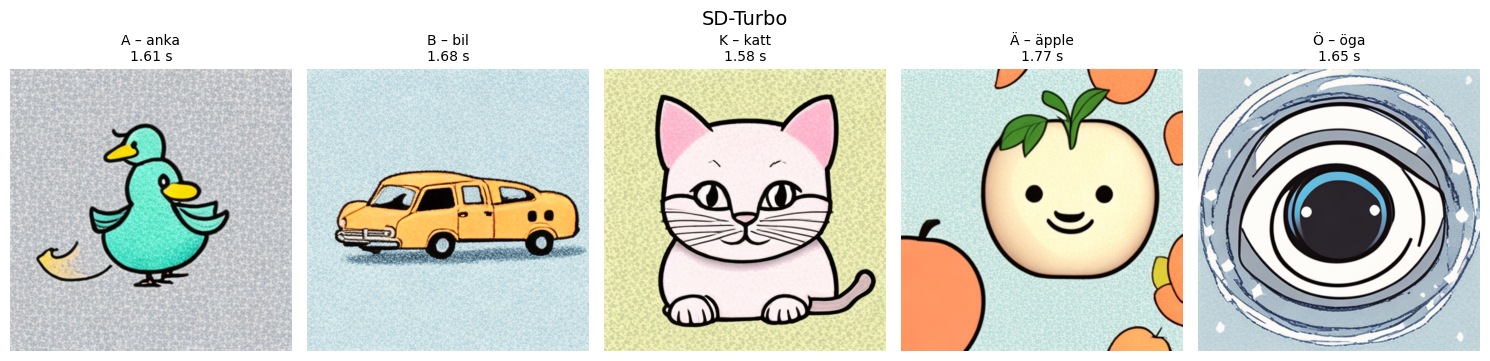

In [16]:
show_results_horizontal(sd_turbo_results)


In [17]:
release_pipeline(sd_turbo)
del sd_turbo


### Observation

SD-Turbo uses only a few denoising steps, so it is useful for comparing speed against image quality.

Because `guidance_scale=0.0` is used, the shared negative prompt is not included in this benchmark.

## Model 3 — SSD-1B

SSD-1B is a distilled SDXL-family model and is the strongest practical local candidate tested so far.

### Download

Run in Terminal:

```bash
hf download segmind/SSD-1B
```

### Why the black images returned

The failed run used an `float16` UNet and text encoders on MPS while only the VAE was `float32`. Its output included the warning `invalid value encountered in cast`; the generated array contained non-finite values, which became zero-valued (black) pixels during conversion to `uint8`. Loading the VAE separately did not stabilize the rest of the half-precision pipeline.

This benchmark therefore loads the **complete SSD-1B pipeline in `float32`**. It uses more unified memory but is the reliable configuration for this machine. The preceding pipelines are released before SSD-1B is loaded, and the shared generator rejects black frames before saving them.


In [18]:
ssd1b = StableDiffusionXLPipeline.from_pretrained(
    "segmind/SSD-1B",
    torch_dtype=torch.float32,
    local_files_only=True,
    use_safetensors=True,
)

ssd1b = ssd1b.to(device)
ssd1b.enable_attention_slicing()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

### Prepare SSD-1B jobs

This cell only prepares prompts, generation settings, and output paths. It does not run the model.


In [19]:
ssd1b_jobs = prepare_generation_jobs(
    model_name="SSD-1B",
    output_folder="model_test_outputs/ssd1b",
    num_inference_steps=25,
    guidance_scale=9.0,
    use_negative_prompt=True,
)

ssd1b_jobs


[{'model': 'SSD-1B',
  'letter': 'A',
  'word': 'anka',
  'object_english': 'duck',
  'image_path': PosixPath('model_test_outputs/ssd1b/A_anka.png'),
  'generation_args': {'prompt': "\n    cute children's illustration of a duck,\n    one duck only,\n    soft pastel colors,\n    clean simple cartoon style,\n    rounded friendly shapes,\n    pure plain white background,\n    no text\n    ",
   'width': 512,
   'height': 512,
   'num_inference_steps': 25,
   'guidance_scale': 9.0,
   'negative_prompt': '\nugly, blurry, distorted,\nextra limbs, extra wings,\nmultiple objects,\ntext, letters, watermark,\nmessy background,\ndark background,\nphotorealistic\n'}},
 {'model': 'SSD-1B',
  'letter': 'B',
  'word': 'bil',
  'object_english': 'car',
  'image_path': PosixPath('model_test_outputs/ssd1b/B_bil.png'),
  'generation_args': {'prompt': "\n    cute children's illustration of a car,\n    one car only,\n    soft pastel colors,\n    clean simple cartoon style,\n    rounded friendly shapes,\n  

### Run SSD-1B

The next cell is the expensive step. The `run_model()` call is where all five images are generated.


In [20]:
ssd1b_runs = run_model(
    pipe=ssd1b,
    generation_jobs=ssd1b_jobs,
)

save_model_outputs(ssd1b_runs)

ssd1b_results = get_results_summary(ssd1b_runs)
ssd1b_results

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

,model,letter,word,object_english,runtime_sec,image_path
0,SSD-1B,A,anka,duck,21.69,model_test_outputs/ssd1b/A_anka.png
1,SSD-1B,B,bil,car,20.59,model_test_outputs/ssd1b/B_bil.png
2,SSD-1B,K,katt,cat,20.57,model_test_outputs/ssd1b/K_katt.png
3,SSD-1B,Ä,äpple,apple,20.46,model_test_outputs/ssd1b/Ä_äpple.png
4,SSD-1B,Ö,öga,eye,20.46,model_test_outputs/ssd1b/Ö_öga.png


### Show the images

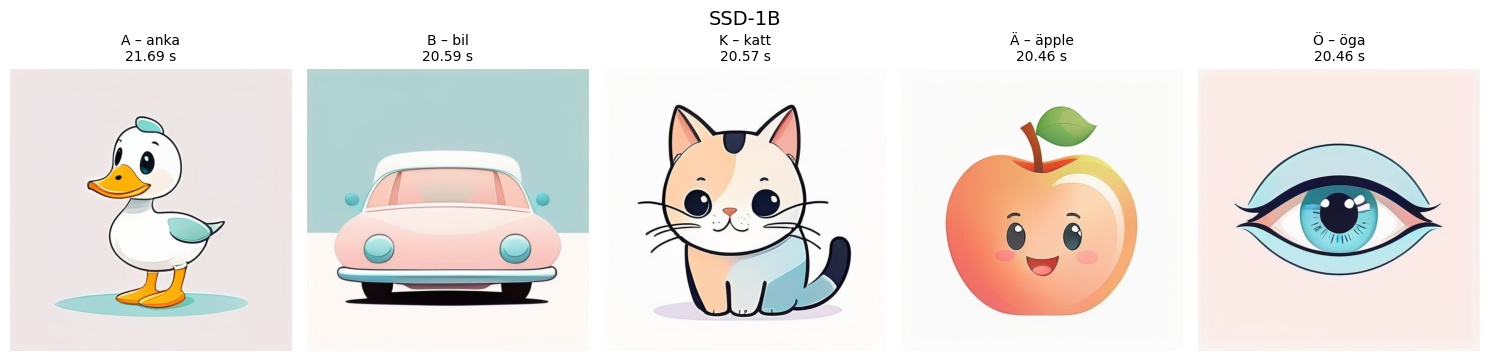

In [21]:
show_results_horizontal(ssd1b_results)


In [22]:
release_pipeline(ssd1b)
del ssd1b


### Observation

SSD-1B is the strongest qualitative candidate, although background compliance must be checked in the final grid. Full `float32` avoids the non-finite-value failure seen in the mixed-precision MPS run.


## 6. Additional experiment — FLUX.1-schnell

FLUX.1-schnell was tested before settling on the three-model comparison above.

### Download

Run in Terminal:

```bash
hf download black-forest-labs/FLUX.1-schnell
```

The model occupied roughly 31+ GB in the local Hugging Face cache during this experiment.

### Attempted loading code

The code used was conceptually:

```python
from diffusers import FluxPipeline

flux = FluxPipeline.from_pretrained(
    "black-forest-labs/FLUX.1-schnell",
    torch_dtype=torch.float16,
    local_files_only=True,
)

flux = flux.to("mps")
```

### Result

On this MacBook Pro (Apple M4, 24 GB unified memory), FLUX caused MPS out-of-memory errors, and a CPU attempt froze the computer.

For this simple flashcard task, FLUX is therefore not included in the active five-image benchmark. It is kept here as a useful record of a model that was **too large for the available hardware**.

## 7. Model comparison

After the three independent generation runs finish, combine their result tables into `all_results`.

This section provides two complementary comparisons:

1. a grouped Plotly bar chart comparing `runtime_sec` for every model and flashcard object;
2. a three-row by five-column image grid, where rows are models and columns are the shared objects.


In [23]:
model_order = ["SD 1.5", "SD-Turbo", "SSD-1B"]
object_order = [item[2] for item in test_objects]

all_results = pd.concat(
    [sd15_results, sd_turbo_results, ssd1b_results],
    ignore_index=True,
)

all_results


,model,letter,word,object_english,runtime_sec,image_path
0,SD 1.5,A,anka,duck,25.31,model_test_outputs/sd15/A_anka.png
1,SD 1.5,B,bil,car,24.91,model_test_outputs/sd15/B_bil.png
2,SD 1.5,K,katt,cat,24.93,model_test_outputs/sd15/K_katt.png
3,SD 1.5,Ä,äpple,apple,25.51,model_test_outputs/sd15/Ä_äpple.png
4,SD 1.5,Ö,öga,eye,26.11,model_test_outputs/sd15/Ö_öga.png
5,SD-Turbo,A,anka,duck,1.61,model_test_outputs/sd_turbo/A_anka.png
6,SD-Turbo,B,bil,car,1.68,model_test_outputs/sd_turbo/B_bil.png
7,SD-Turbo,K,katt,cat,1.58,model_test_outputs/sd_turbo/K_katt.png
8,SD-Turbo,Ä,äpple,apple,1.77,model_test_outputs/sd_turbo/Ä_äpple.png
9,SD-Turbo,Ö,öga,eye,1.65,model_test_outputs/sd_turbo/Ö_öga.png


### Interactive runtime comparison

Each flashcard object forms one group on the x-axis, with one bar per model. The y-axis shows generation time in seconds.


In [51]:
import plotly.express as px
from IPython.display import display
import plotly.io as pio

# Load Plotly.js from the internet instead of embedding it
pio.renderers.default = "notebook_connected"

# Keep the original all_results DataFrame unchanged.
runtime_plot_data = all_results.copy()
runtime_plot_data["flashcard"] = (
    runtime_plot_data["letter"]
    + " – "
    + runtime_plot_data["word"]
)

runtime_bar = px.bar(
    runtime_plot_data,
    x="flashcard",
    y="runtime_sec",
    color="model",
    barmode="group",
    text="runtime_sec",
    category_orders={
        "flashcard": [f"{letter} – {word}" for letter, word, _ in test_objects],
        "model": model_order,
    },
    color_discrete_map={
        "SD 1.5": "#4C78A8",
        "SD-Turbo": "#F58518",
        "SSD-1B": "#54A24B",
    },
    hover_data={
        "runtime_sec": ":.2f",
        "flashcard": False,
    },
    labels={
        "flashcard": "Flashcard",
        "runtime_sec": "Runtime",
        "model": "Model",
    },
)

runtime_bar.update_traces(
    texttemplate="%{text:.2f} s",
    textposition="outside",
    cliponaxis=False,
)
runtime_bar.update_layout(
    yaxis_title="Runtime (seconds)",
    legend_title="Model",
    hovermode="x unified",
    bargap=0.18,
    margin=dict(l=50, r=20, t=50, b=30),
)

display(runtime_bar)


### Image comparison

/var/folders/p0/n7yvvjm11b9b0fwk19kmm5l00000gn/T/ipykernel_14633/4077035906.py:50: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(rect=(0, 0, 0, 0))


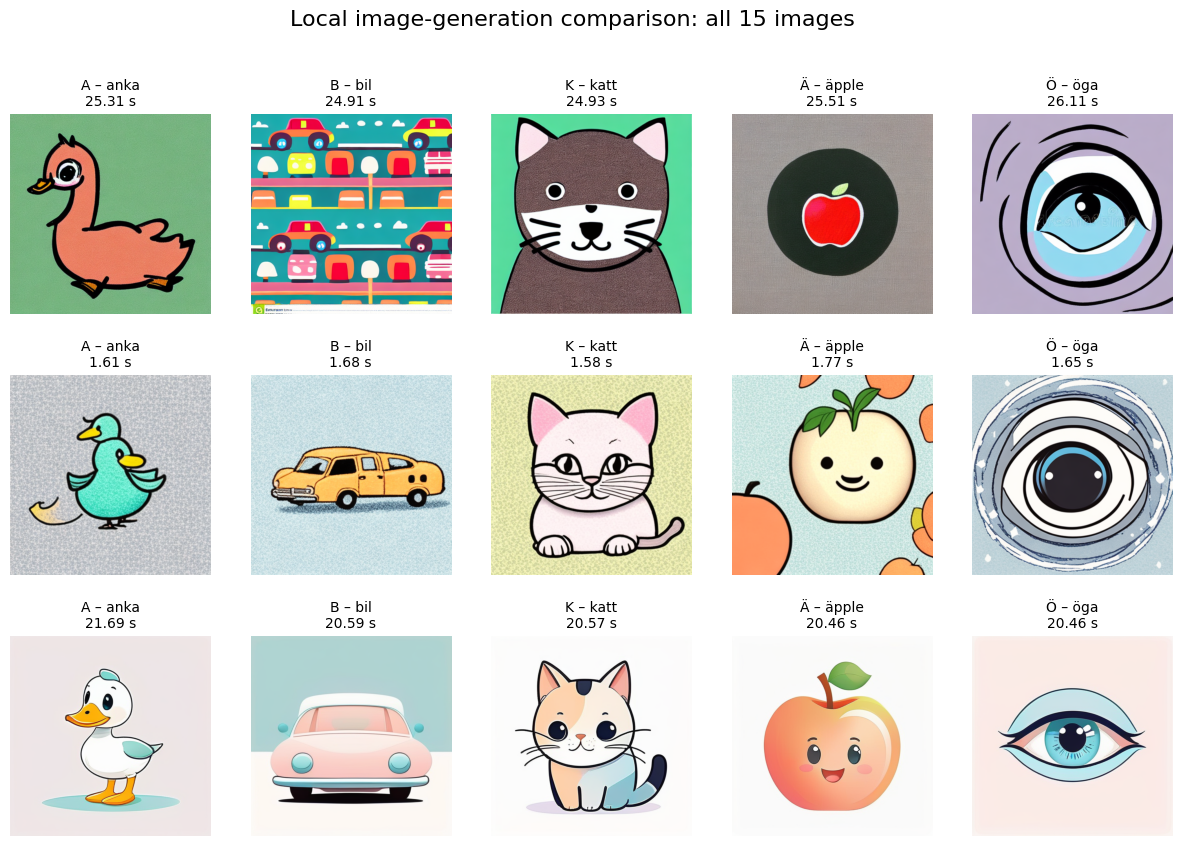

In [36]:
show_comparison_grid(
    all_results,
    model_order=model_order,
    object_order=object_order,
    output_path="model_test_outputs/comparison_all_15.png",
)


In [37]:
runtime_summary = (
    all_results
    .groupby("model", as_index=False)["runtime_sec"]
    .agg(
        average_runtime_sec="mean",
        min_runtime_sec="min",
        max_runtime_sec="max",
    )
    .round(2)
)

runtime_summary

,model,average_runtime_sec,min_runtime_sec,max_runtime_sec
0,SD 1.5,25.35,24.91,26.11
1,SD-Turbo,1.66,1.58,1.77
2,SSD-1B,20.75,20.46,21.69


## 8. Comparison results

The rating table combines the 15-image visual inspection with measured runtime. Scores use a five-point scale, where 5 is best. Because image generation is stochastic, the qualitative scores describe this saved benchmark run rather than every possible output from each model.

| Model | Recogn. | Style | Prompt | Stability | Speed | Summary |
|---|---:|---:|---:|---:|---:|---|
| SD 1.5 | 4 | 3 | 2 | 4 | 3 | Recognisable but inconsistent; backgrounds and composition often miss the simple one-object brief. |
| SD-Turbo | 4 | 4 | 3 | 5 | 1 | By far the fastest and usually recognisable; quality is simpler and CFG 0 cannot use the negative prompt. |
| SSD-1B | 5 | 5 | 4 | 4 | 2 | Best detail and flashcard quality; slower than Turbo and requires full float32 on this MPS setup. |


## 9. Conclusion

- **Best overall image quality: SSD-1B.** It produces the strongest, most polished flashcard illustrations in this benchmark. It is the preferred model when quality matters more than latency, but it must use full `float32` on this Mac to avoid black images.
- **Best speed: SD-Turbo.** At roughly 1–2 seconds per image in the recorded run, it is dramatically faster. It is the practical choice for rapid drafts, although prompt control and consistency are weaker.
- **Third place: Stable Diffusion 1.5.** The objects are generally recognisable, but it is the slowest recorded model and follows the white-background/single-object brief least consistently.
- **Not practical locally: FLUX.1-schnell.** Its memory requirement exceeds the comfortable capacity of this 24 GB machine.

The most important SSD-1B lesson is that a `float32` VAE alone is insufficient when other pipeline components still run unstable `float16` calculations on MPS. The full-pipeline `float32` configuration, pipeline cleanup between models, and black-frame validation together make the benchmark reliable.
